In [10]:
import os
from torch_em.data.datasets.light_microscopy.covid_if import (
    get_covid_if_data
)
import os
from glob import glob
from typing import Optional, Union, Tuple

import h5py
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label as connected_components

import torch

from torch_em.util.util import get_random_colors
from torch_em.data.datasets.light_microscopy.covid_if import get_covid_if_data, get_covid_if_dataset, get_covid_if_loader

from micro_sam.evaluation.model_comparison import _enhance_image
from micro_sam.automatic_segmentation import get_predictor_and_segmenter, automatic_instance_segmentation

# Download Data

In [ ]:
# root_dir = "/g/kreshuk/talks/data"
# data_dir = os.path.join(root_dir,"covid_if")
# get_covid_if_data(path=data_dir, download=True)

Download https://zenodo.org/record/5092850/files/covid-if-groundtruth.zip?download=1 to /g/kreshuk/talks/data/covid_if/covid-if.zip: 100%|██████████| 491M/491M [00:18<00:00, 28.1MB/s] 


Download successful and checksums agree.


'/g/kreshuk/talks/data/covid_if'

# View Data

In [2]:
# Convenience function to plot images side-by-side
def plot_samples(image, gt, segmentation=None, enhance_image=True):
    n_images = 2 if segmentation is None else 3
    fig, ax = plt.subplots(1, n_images, figsize=(10, 10))

    if enhance_image:
        image = _enhance_image(image, do_norm=True)

    ax[0].imshow(image, cmap="gray")
    ax[0].axis("off")
    ax[0].set_title("Image")

    gt = connected_components(gt)
    ax[1].imshow(gt, cmap=get_random_colors(gt), interpolation="nearest")
    ax[1].axis("off")
    ax[1].set_title("Ground Truth")

    if n_images == 3:
        ax[2].imshow(segmentation, cmap=get_random_colors(segmentation), interpolation="nearest")
        ax[2].axis("off")
        ax[2].set_title("Prediction")

    plt.show()
    plt.close()

In [3]:
data_dir = "/g/kreshuk/talks/data/covid_if"

(1024, 1024)


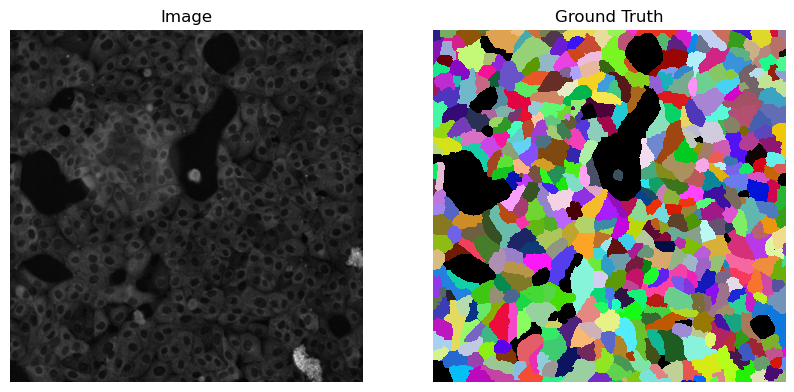

In [7]:
sample_paths = sorted(glob(os.path.join(data_dir, "*")))

for sample_path in sample_paths:
    with h5py.File(sample_path, "r") as f:
        raw = f["raw/serum_IgG/s0"][:]
        labels = f["labels/cells/s0"][:]
    

    print(raw.shape)

    plot_samples(image=raw, gt=labels)

    break  # comment this out in case you want to visualize all images.

# COVID_IF Dataset

In [26]:
dataset = get_covid_if_dataset(
    path = data_dir,
    patch_shape=(512,512),
    target="cells",
    download=False,
)

In [27]:
len(dataset)

196

In [24]:
dataloader = get_covid_if_loader(
    path = data_dir,
    patch_shape=(512,512),
    batch_size = 5,
    sample_range=(0,10),
    target='cells',
)

In [25]:
img, target = next(iter(dataloader))
img.shape, target.shape

(torch.Size([5, 1, 512, 512]), torch.Size([5, 1, 512, 512]))

torch.Size([1, 1024, 1024]) torch.Size([1, 1024, 1024])


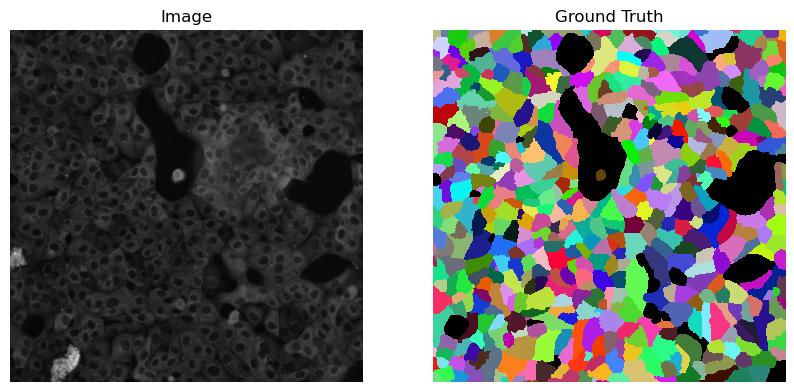

torch.Size([1, 1024, 1024]) torch.Size([1, 1024, 1024])


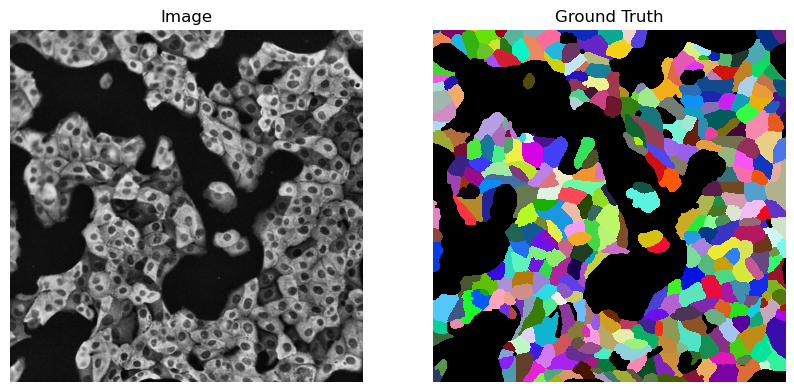

torch.Size([1, 1024, 1024]) torch.Size([1, 1024, 1024])


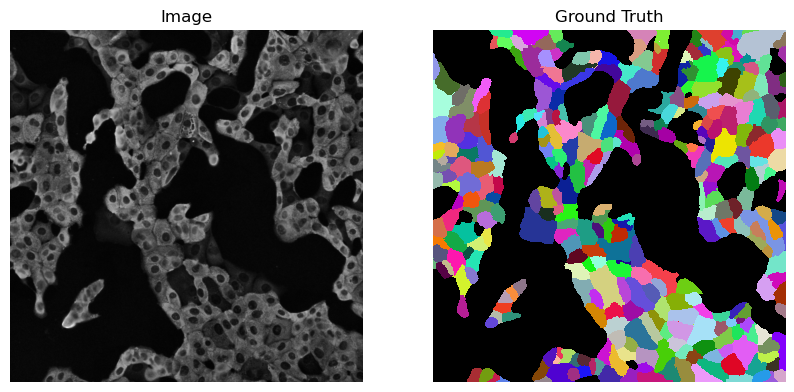

torch.Size([1, 1024, 1024]) torch.Size([1, 1024, 1024])


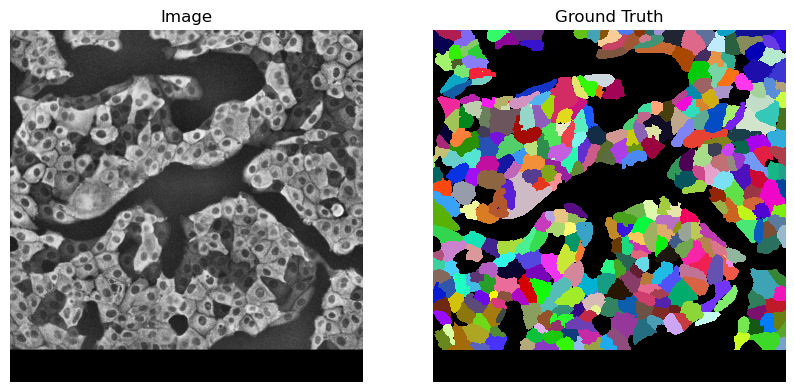

torch.Size([1, 1024, 1024]) torch.Size([1, 1024, 1024])


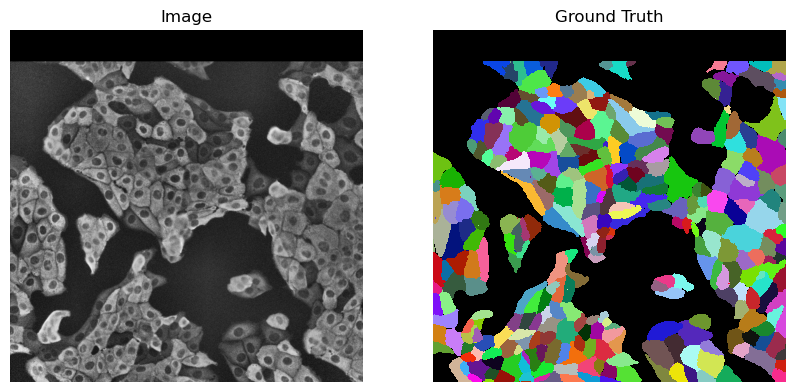

In [21]:
for img, label in dataset:
    print(img.shape, label.shape)
    plot_samples(img[0].numpy(), label[0].numpy())
